# **Modelos secuenciales: LSTM inter-época e híbrido CNN1D $\to$ BiLSTM**

Este cuaderno entrena y compara los **dos modelos secuenciales** del proyecto con **una sola función** (`src.lstm.train`) y el **mismo split por sujeto**, para que sus métricas sean directamente comparables:

1. **LSTM tabular** (`hybrid=False`): una BiLSTM many-to-many sobre la secuencia de **features handcrafted** por época (`epoch_features.csv`). El encoder intra-época es `IdentityEncoder` (pasa las features tal cual). Modela la **dinámica inter-época**.
2. **Híbrido CNN1D $\to$ BiLSTM** (`hybrid=True`): una **CNN 1D** (`CNNEpochEncoder`) resume la **señal cruda** de cada época (`sequences/*.npz`, `[150, 4]`) en un vector, y la BiLSTM lee esa secuencia. Se entrena **end-to-end** (una sola loss ajusta CNN y LSTM juntas). Combina morfología **intra-época** y dinámica **inter-época**.

## Arquitectura común
$$\text{época}[\dots] \;\xrightarrow{\text{encoder}}\; [T, F_{enc}] \;\xrightarrow{\text{BiLSTM (2 capas)}}\; \text{Dropout} \to \text{Linear} \to \text{logits}[T, 5]$$

- **encoder**: `IdentityEncoder` (tabular, $F_{enc}=122$) o `CNNEpochEncoder` (híbrido, $F_{enc}=128$). Es el único punto que cambia entre modos.
- **BiLSTM**: `hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True`. Lee la noche hacia adelante y hacia atrás (sleep staging offline → sin restricción de causalidad).
- **Padding + packing**: las noches tienen largo variable; `collate_nights` paddea al máximo del batch (features con 0.0, labels con `UNKNOWN=5`) y `pack_padded_sequence` hace que la LSTM ignore el relleno. La loss usa `ignore_index=UNKNOWN` (Unknown + padding fuera de la loss y de las métricas).
- **Loss**: `CrossEntropyLoss` con **pesos de clase** inversos a la frecuencia (desbalance N2 ≫ N1) + **gradient clipping**.

## Split y comparabilidad
El split es **por sujeto** (`partition_subjects`, sujetos disjuntos train/val/test), con la **misma seed y fracciones** para los dos modelos $\implies$ **exactamente los mismos sujetos** en cada partición. Así la diferencia de Kappa entre LSTM e híbrido refleja el modelo, no la partición.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, glob
sys.path.append("..")

# import temprano de torch._dynamo: evita un fallo de sympy con kernel de estado sucio.
import torch
import torch._dynamo  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.lstm import (ConfigLSTM, train_final, evaluate, plot_history, predict_night,
                      STAGE_NAMES, COLLAPSE_4_NAMES, collapse4_labels, collapse4_scores)
from src.sequence_data import build_night_sequences
from src.feature_extraction import feature_extraction
from src.tuning import run_search, best_config
from src.plots import night_prediction_overview
from src.metrics import print_metrics, plot_confusion, roc_pr_curves

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos (se generan solo si faltan)

- **`epoch_features.csv`** (modo tabular): lo produce `baseline.ipynb` (feature extraction). Si no existe, se genera acá.
- **`sequences/*.npz`** (modo híbrido): señal cruda por noche + `night_id`.

Ambos derivan de los mismos pacientes, así que el split por sujeto coincide entre modos.

In [2]:
FEATURES = "../data_extraction/epoch_features.csv"
if os.path.exists(FEATURES):
    print(f"{FEATURES} ya existe; se omite la extracción.")
else:
    feature_extraction()

SEQ_DIR = "../data_extraction/sequences"
if glob.glob(os.path.join(SEQ_DIR, "*.npz")):
    print(f"{SEQ_DIR} ya tiene datos; se omite el procesamiento.")
else:
    build_night_sequences(output_dir=SEQ_DIR)

../data_extraction/epoch_features.csv ya existe; se omite la extracción.
../data_extraction/sequences ya tiene datos; se omite el procesamiento.


## 2. Configuración y split compartido

Dos `ConfigLSTM` que difieren solo en el modo (`hybrid`) y el checkpoint. La **misma seed** garantiza el **mismo split por sujeto** para los dos. `TRAIN_NEW` es la constante universal entrenar-de-cero / usar-guardado.

In [3]:
TRAIN_NEW = True  # True: entrena de cero y sobreescribe el checkpoint; False: usa el .pt guardado

# configuraciones default
cfg_lstm = ConfigLSTM(hybrid=False, ckpt_path="../models/best_lstm.pt",
                      epochs=60, patience=15)
cfg_hyb = ConfigLSTM(hybrid=True,  ckpt_path="../models/best_hybrid.pt",
                      hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True,
                      batch_size=8, lr=1e-3, epochs=100, patience=10, use_class_weights=True)

## 3. Búsqueda bayesiana de hiperparámetros (Optuna)

Antes de entrenar los modelos "finales" buscamos buenos hiperparámetros con **búsqueda bayesiana** en lugar de probar a mano o hacer *grid search*.

**¿Qué es?** El *grid/random search* prueba configuraciones **a ciegas**. La búsqueda bayesiana construye un **modelo probabilístico** de la relación *hiperparámetros $\to$ métrica* y, a partir de los trials ya evaluados, propone la **siguiente configuración más prometedora** (equilibrando explorar zonas nuevas y explotar las que rindieron bien). Así llega a buenas configuraciones con **muchos menos entrenamientos**.

**Cómo lo hacemos (`src/tuning.py`, con [Optuna](https://optuna.org/)):**
- El sampler **TPE** (*Tree-structured Parzen Estimator*) implementa la parte bayesiana.
- **Objetivo a maximizar: el Cohen's Kappa del set de _validación_**. Se toma el kappa del mejor epoch, igual criterio con que `train` guarda el checkpoint.
- Espacio de búsqueda (`default_space`): `hidden_size`, `num_layers`, `dropout`, `lr`, `weight_decay`, `batch_size` (+ `feature_dim` en el híbrido). El resto de la config (seed, fracciones del split, `hybrid`, paths) queda **fijo** ⇒ split por sujeto idéntico entre trials y entre modelos.
- **Se corren dos búsquedas independientes**, una por modelo.

**Costo y optimizaciones (clave en el híbrido).** El híbrido es mucho más pesado que el tabular: corre una CNN por época de cada noche (~24–27 s/epoch con `feature_dim=128`, más con 256), todo en GPU. Para que el search sea viable:
- **`search_epochs`**: cada trial entrena menos epochs que el entrenamiento final (acá 25 tabular / 15 híbrido). Basta para **rankear** configs; al ganador se lo re-entrena con todas las epochs vía `USE_BEST`.
- **MedianPruner**: corta un trial apenas su kappa de val cae por debajo de la mediana de los previos al mismo epoch. Los trials podados **no** se guardan en el CSV.
- **AMP (mixed precision)**: `train` usa `autocast`+`GradScaler` en GPU (flag `cfg.amp`, auto-on en cuda). Baja memoria; el extra de velocidad es modesto acá porque la LSTM casi no se acelera.

**Persistencia (para correr el search en varias instancias):** cada estudio se guarda en `models/searchs/<name>.db` (SQLite $\to$ **resume** donde quedó y el TPE aprovecha todo el historial) y en `models/searchs/<name>.csv`, un log legible con **toda la config** de cada trial + su `kappa/macro_f1/accuracy` de val. Cada corrida **agrega** sus trials nuevos (no reescribe) y deja el CSV **ordenado por kappa descendente**. `best_config(base_cfg, name)` levanta del CSV los mejores hiperparámetros sobre la config base (conservando `epochs`/paths de la base).

In [4]:
RUN_SEARCH = False  # True: corre N_TRIALS de búsqueda bayesiana por modelo.
N_TRIALS = 5       # trials POR ejecución.

if RUN_SEARCH:
    run_search(cfg_lstm, name="lstm", n_trials=N_TRIALS, search_epochs=25)
    run_search(cfg_hyb, name="hybrid", n_trials=N_TRIALS, search_epochs=15)

In [5]:
USE_BEST = True  # True: reemplaza los hiperparámetros de las configuraciones por los mejores del search
			     # False: utiliza hiperparámetros de las configuraciones default

if USE_BEST:
    cfg_lstm = best_config(cfg_lstm, "lstm")
    cfg_hyb = best_config(cfg_hyb, "hybrid")
    print("cfg_lstm ->", cfg_lstm)
    print("cfg_hyb  ->", cfg_hyb)

cfg_lstm -> ConfigLSTM(hybrid=False, features_path='../data_extraction/epoch_features.csv', sequences_dir='../data_extraction/sequences', feature_dim=128, hidden_size=128, num_layers=2, dropout=0.3652272824493826, bidirectional=True, batch_size=4, lr=0.0010675227795271, weight_decay=3.8670718114899184e-05, epochs=60, grad_clip=5.0, use_class_weights=True, amp=None, patience=15, refit_trainval=False, val_frac=0.15, test_frac=0.15, seed=36631, device='cuda', ckpt_path='../models/best_lstm.pt', feature_cols=None, input_size=None)
cfg_hyb  -> ConfigLSTM(hybrid=True, features_path='../data_extraction/epoch_features.csv', sequences_dir='../data_extraction/sequences', feature_dim=256, hidden_size=128, num_layers=3, dropout=0.4366107897120125, bidirectional=True, batch_size=8, lr=0.0005811604803142, weight_decay=4.078835816332079e-05, epochs=100, grad_clip=5.0, use_class_weights=True, amp=None, patience=10, refit_trainval=False, val_frac=0.15, test_frac=0.15, seed=36631, device='cuda', ckpt_pa

## 4. Entrenamiento final en dos fases (train+val → test)

Una vez fijados los hiperparámetros (por el search, o los default), cada modelo final se entrena con **`train_final`**, que separa *elegir cuándo parar* de *entrenar el modelo definitivo*, **sin tocar nunca test**:

- **Fase 1 — presupuesto de epochs (con val).** Se entrena con `train` y se valida con `val` (early stopping por Cohen's Kappa de validación). De acá sale `best_epoch` = la época del mejor kappa de val, y las **curvas train/val** de la sección 5.
- **Fase 2 — refit (train+val).** Se reentrena el modelo **de cero** usando **train + val** como entrenamiento, por exactamente `best_epoch` epochs (sin val ni early stopping). Ese modelo es el que se guarda y el que se **evalúa en test**.

Así el modelo definitivo aprovecha ~15% más de datos (los sujetos de val) y el nº de epochs no es arbitrario sino el que la validación señaló. **No hay leakage sobre test**: val se usa solo para fijar el presupuesto de epochs (como cualquier hiperparámetro), igual que `refit=True` en `GridSearchCV`. Las métricas reportadas salen del modelo reentrenado con train+val, medido en test.

## 5. BiLSTM tabular (inter-época)

BiLSTM sobre las 122 features handcrafted ([epoch_features.csv](data_extraction/epoch_features.csv)).

In [6]:
if TRAIN_NEW or not os.path.exists(cfg_lstm.ckpt_path):
    model_lstm, hist_lstm, test_lstm = train_final(cfg_lstm)
else:
    model_lstm, test_lstm = evaluate(cfg_lstm)
    hist_lstm = None

Early Stop (LSTM) - epoch 38 (mejor 0.4680 @ 23):  62%|██████▏   | 37/60 [08:10<05:05, 13.27s/epoch, train_loss=0.4378, val_loss=1.5502, val_kappa=0.4316, best=0.4680]



TEST (LSTM) — mejor ckpt (val kappa 0.4680, epoch 23):
  kappa 0.4549 | macroF1 0.5643 | acc 0.5805
  4-clases: kappa 0.4888 | macroF1 0.6487 | acc 0.6501

[refit LSTM tabular] fase 2: reentreno sobre train+val por 23 epochs (mejor epoch de val en fase 1)


Training (LSTM): 100%|██████████| 23/23 [04:38<00:00, 12.11s/epoch, train_loss=0.7409]



TEST (LSTM) — mejor ckpt (val kappa nan, epoch 23):
  kappa 0.4647 | macroF1 0.5702 | acc 0.5884
  4-clases: kappa 0.4927 | macroF1 0.6534 | acc 0.6526


## 6. Híbrido CNN1D $\to$ BiLSTM

La misma `train`, con `hybrid=True`: el `CNNEpochEncoder` (GroupNorm, robusto al padding) resume cada época de señal cruda `[150, 4]` en 128 features y la BiLSTM lee la secuencia. Más lento (la CNN corre sobre todas las épocas de cada noche); conviene GPU.

In [7]:
if TRAIN_NEW or not os.path.exists(cfg_hyb.ckpt_path):
    model_hyb, hist_hyb, test_hyb = train_final(cfg_hyb)
else:
    model_hyb, test_hyb = evaluate(cfg_hyb)
    hist_hyb = None

Early Stop (Hybrid) - epoch 57 (mejor 0.3875 @ 47):  56%|█████▌    | 56/100 [25:58<20:24, 27.82s/epoch, train_loss=1.0257, val_loss=1.1482, val_kappa=0.3408, best=0.3875]



TEST (Hybrid) — mejor ckpt (val kappa 0.3875, epoch 47):
  kappa 0.3355 | macroF1 0.4714 | acc 0.4739
  4-clases: kappa 0.3534 | macroF1 0.5461 | acc 0.5560

[refit híbrido CNN1D->BiLSTM] fase 2: reentreno sobre train+val por 47 epochs (mejor epoch de val en fase 1)


Training (Hybrid): 100%|██████████| 47/47 [20:17<00:00, 25.90s/epoch, train_loss=1.0399]



TEST (Hybrid) — mejor ckpt (val kappa nan, epoch 47):
  kappa 0.3583 | macroF1 0.4778 | acc 0.4791
  4-clases: kappa 0.3959 | macroF1 0.5694 | acc 0.5703


## 7. Curvas de entrenamiento (train vs validación)

Para cada modelo: (izq) loss de **train vs validación** por epoch - si divergen, sobreajuste; (der) métricas de **validación** (kappa/macro-F1/accuracy) que muestran en qué epoch quedó el mejor checkpoint.

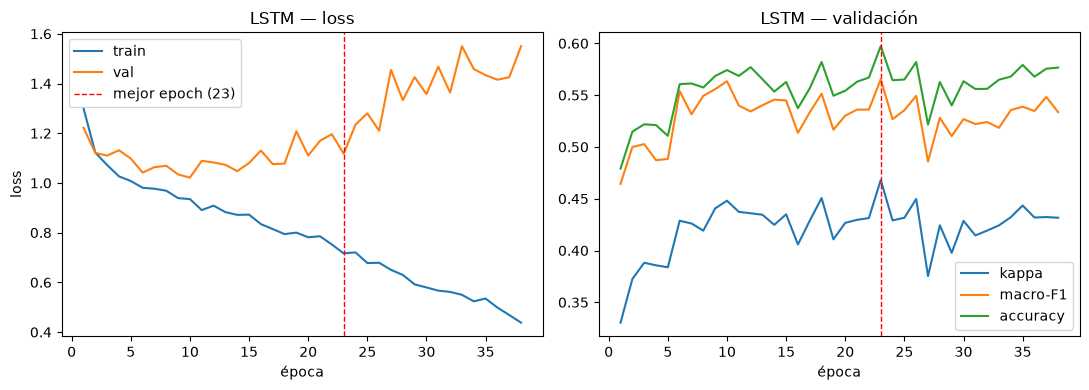

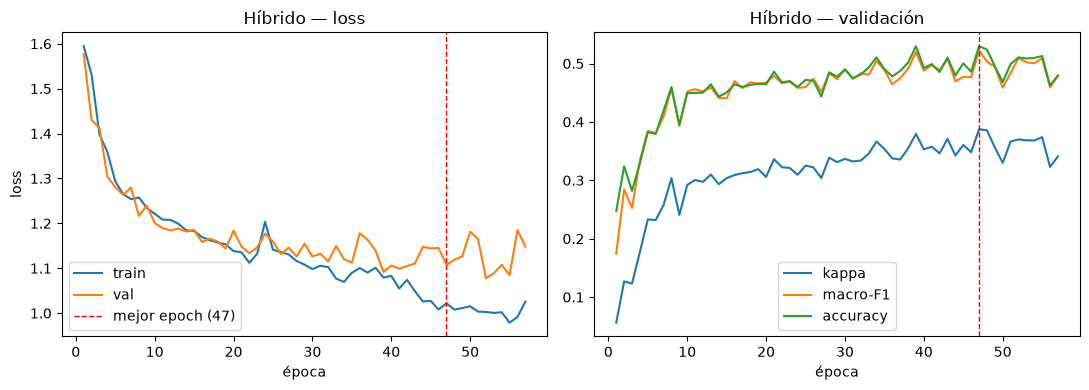

In [8]:
for name, hist in [('LSTM', hist_lstm), ('Híbrido', hist_hyb)]:
    if hist is None:
        print(f"{name}: sin history (TRAIN_NEW=False); se omiten las curvas.")
    else:
        plot_history(hist, title=name)
        plt.tight_layout(); plt.show()

## 8. Comparación en test (mismo split)

Métricas de test de los dos modelos, calculadas sobre el **mismo test set por sujeto**. Para cada modelo se reporta el juego **completo** de métricas tanto en la clasificación de **5 clases** (Wake/N1/N2/N3/REM) como en la vista colapsada a **4 clases** (Wake / Light=N1+N2 / Deep=N3 / REM):

- **Cohen's Kappa** (métrica principal), **F1 macro** y **F1 micro**, **accuracy**.
- **Matriz de confusión** (`plot_confusion`).
- **Curvas ROC + AUC-ROC** y **Precision-Recall + AUC-PR** one-vs-rest (`roc_pr_curves`; el AUC/AP por clase va en la leyenda y el promedio macro en el título).

Todo desde `src/metrics.py`, las mismas funciones que usan los demás notebooks. Las métricas y curvas de 4 clases se obtienen colapsando `y_true`/`y_pred` (`collapse4_labels`) y las probabilidades por clase (`collapse4_scores`).

Test (mismo split por sujeto, vs Expert):
          kappa  f1_macro  f1_micro  accuracy  kappa_4  f1_macro_4  f1_micro_4  accuracy_4
modelo                                                                                    
LSTM     0.4647    0.5702    0.5884    0.5884   0.4927      0.6534      0.6526      0.6526
Híbrido  0.3583    0.4778    0.4791    0.4791   0.3959      0.5694      0.5703      0.5703

===== LSTM tabular — 5 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake       0.74      0.59      0.66      3361
          N1       0.25      0.39      0.30      2776
          N2       0.71      0.52      0.60     11481
          N3       0.67      0.80      0.73      5654
         REM       0.53      0.62      0.57      6222

    accuracy                           0.59     29494
   macro avg       0.58      0.58      0.57     29494
weighted avg       0.62      0.59      0.60     29494

Cohen's Kappa:  0.465
F1 macro:       0.570
F1 mic

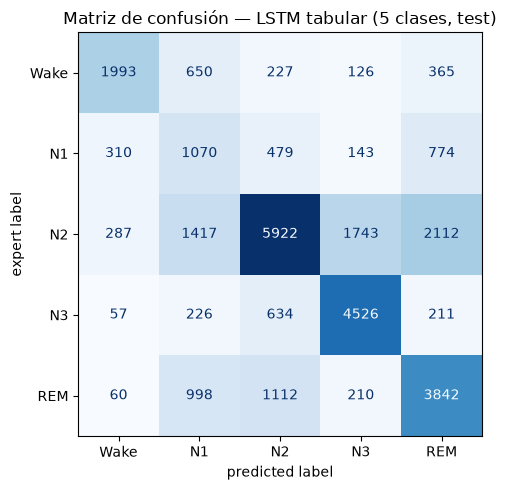

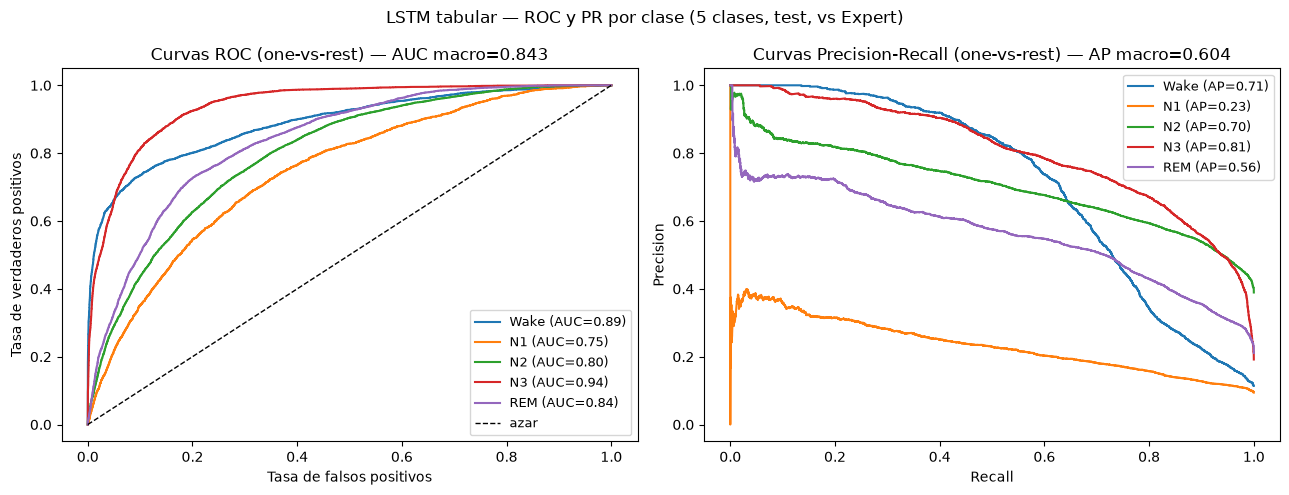


===== LSTM tabular — 4 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake       0.74      0.59      0.66      3361
       Light       0.70      0.62      0.66     14257
        Deep       0.67      0.80      0.73      5654
         REM       0.53      0.62      0.57      6222

    accuracy                           0.65     29494
   macro avg       0.66      0.66      0.65     29494
weighted avg       0.66      0.65      0.65     29494

Cohen's Kappa:  0.493
F1 macro:       0.653
F1 micro:       0.653
Accuracy:       0.653


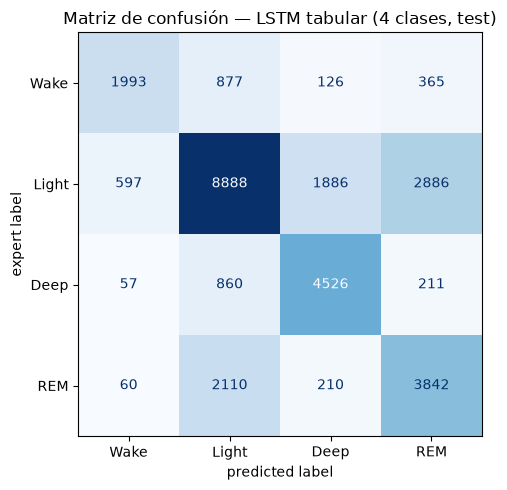

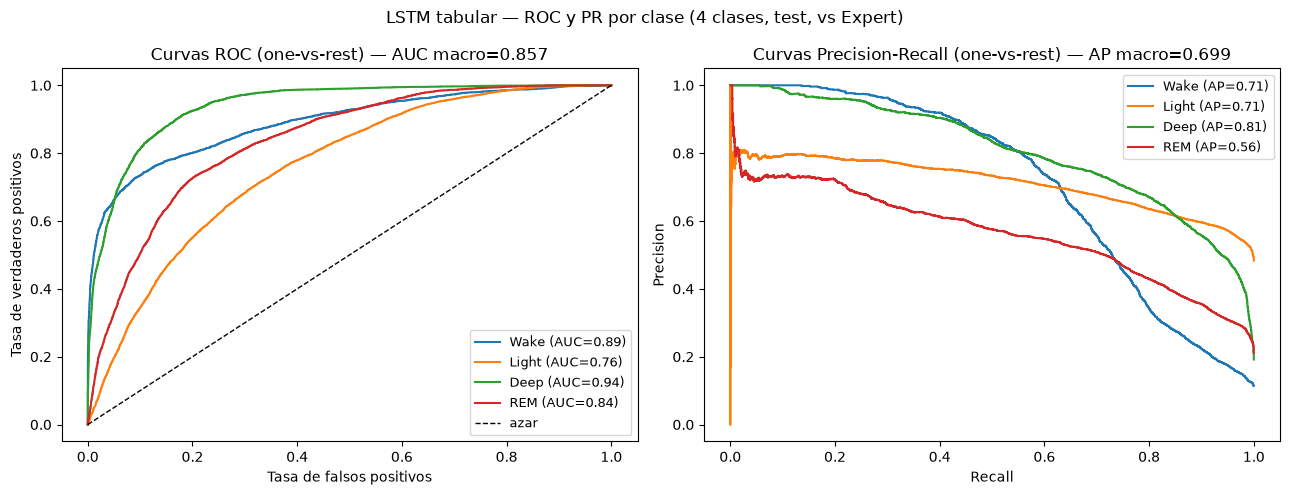


===== Híbrido — 5 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake       0.45      0.69      0.54      3361
          N1       0.20      0.48      0.29      2776
          N2       0.75      0.27      0.39     11481
          N3       0.60      0.72      0.66      5654
         REM       0.48      0.54      0.51      6222

    accuracy                           0.48     29494
   macro avg       0.50      0.54      0.48     29494
weighted avg       0.58      0.48      0.48     29494

Cohen's Kappa:  0.358
F1 macro:       0.478
F1 micro:       0.479
Accuracy:       0.479


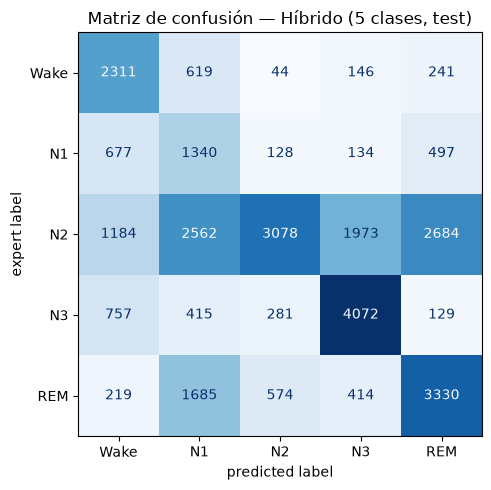

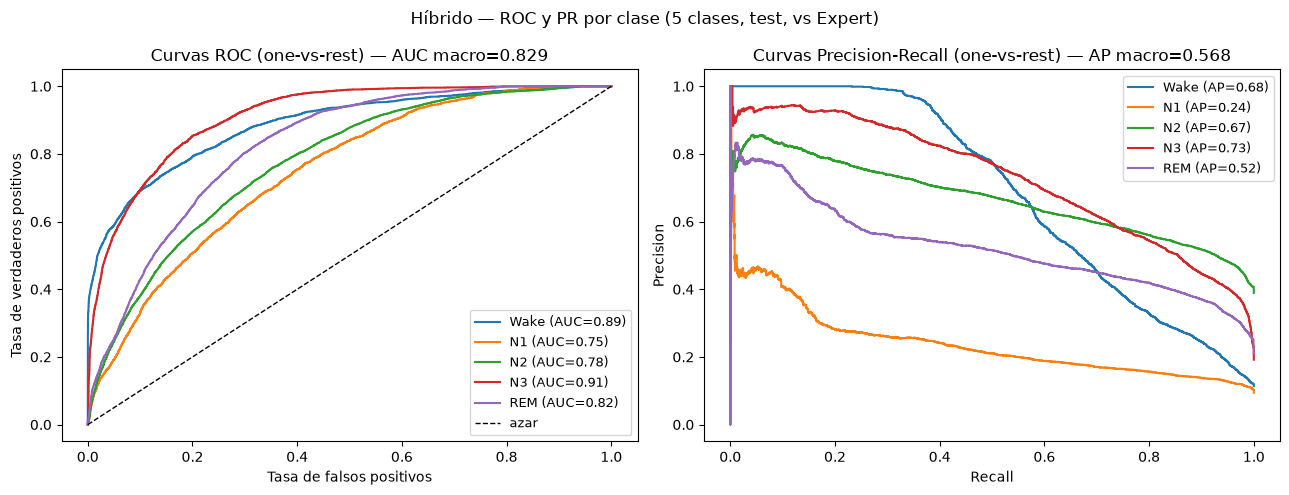


===== Híbrido — 4 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake       0.45      0.69      0.54      3361
       Light       0.66      0.50      0.57     14257
        Deep       0.60      0.72      0.66      5654
         REM       0.48      0.54      0.51      6222

    accuracy                           0.57     29494
   macro avg       0.55      0.61      0.57     29494
weighted avg       0.59      0.57      0.57     29494

Cohen's Kappa:  0.396
F1 macro:       0.569
F1 micro:       0.570
Accuracy:       0.570


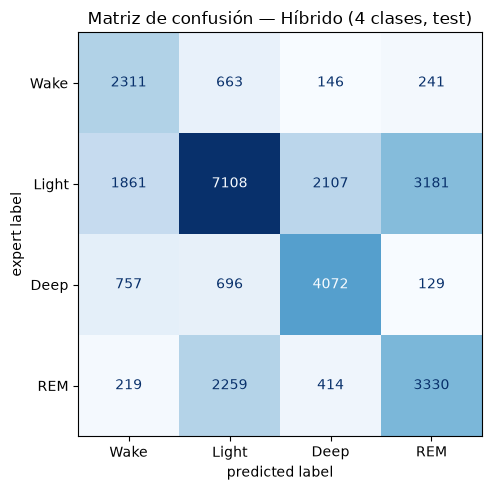

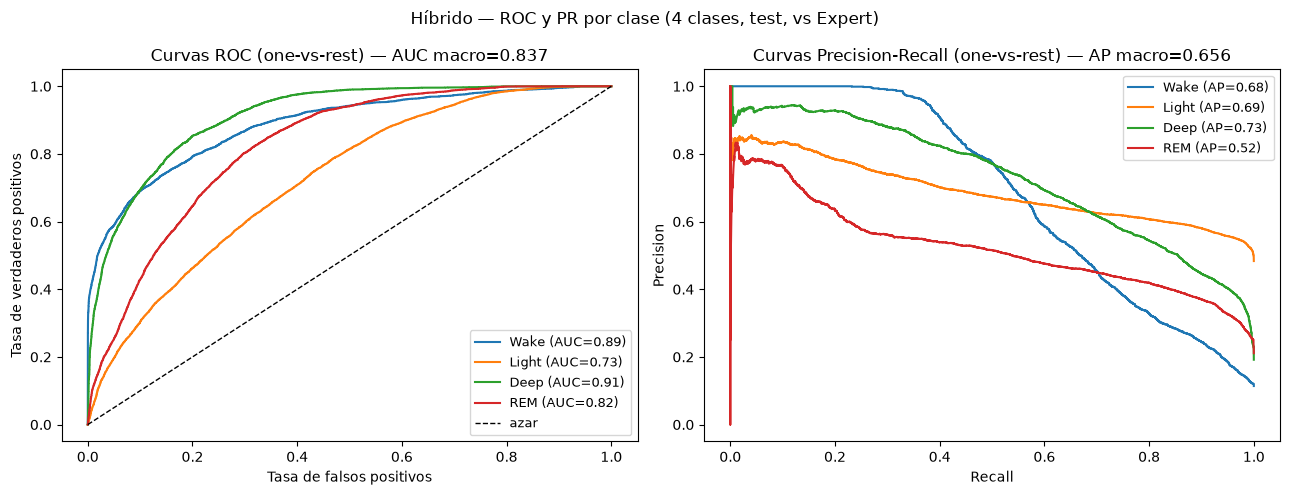

In [9]:
# tabla comparativa: kappa, F1 macro/micro y accuracy en 5 y 4 clases
rows = []
for name, tm in [('LSTM', test_lstm), ('Híbrido', test_hyb)]:
    rows.append({'modelo': name,
                 'kappa': tm['kappa'], 'f1_macro': tm['macro_f1'],
                 'f1_micro': tm['micro_f1'], 'accuracy': tm['accuracy'],
                 'kappa_4': tm['kappa_4'], 'f1_macro_4': tm['macro_f1_4'],
                 'f1_micro_4': tm['micro_f1_4'], 'accuracy_4': tm['accuracy_4']})
summary = pd.DataFrame(rows).set_index('modelo').round(4)
print("Test (mismo split por sujeto, vs Expert):")
print(summary.to_string())

# juego completo de métricas por modelo, en 5 y 4 clases
views = [
    ('5 clases', STAGE_NAMES, lambda tm: (tm['y_true'], tm['y_pred'], tm['y_score'])),
    ('4 clases', COLLAPSE_4_NAMES, lambda tm: (collapse4_labels(tm['y_true']),
                                               collapse4_labels(tm['y_pred']),
                                               collapse4_scores(tm['y_score']))),
]
for name, tm in [('LSTM tabular', test_lstm), ('Híbrido', test_hyb)]:
    for view_name, class_names, get in views:
        yt, yp, ys = get(tm)
        print_metrics(yt, yp, class_names=class_names,
                      name=f'\n===== {name} — {view_name} (test, vs Expert) =====')
        plot_confusion(yt, yp, class_names=class_names,
                       title=f'Matriz de confusión — {name} ({view_name}, test)')
        plt.show()
        roc_pr_curves(yt, ys, class_names=class_names,
                      title=f'{name} — ROC y PR por clase ({view_name}, test, vs Expert)')
        plt.show()

## 9. Overview de una noche con las predicciones

Como el `night_overview` del EDA, pero agregando debajo de las señales los **hipnogramas** de Expert, Dreem y las predicciones de **ambos modelos** (LSTM tabular e híbrido), alineados por índice de época. Permite ver *dónde* acierta o falla cada modelo a lo largo de la noche (típicamente en las transiciones y en N1).

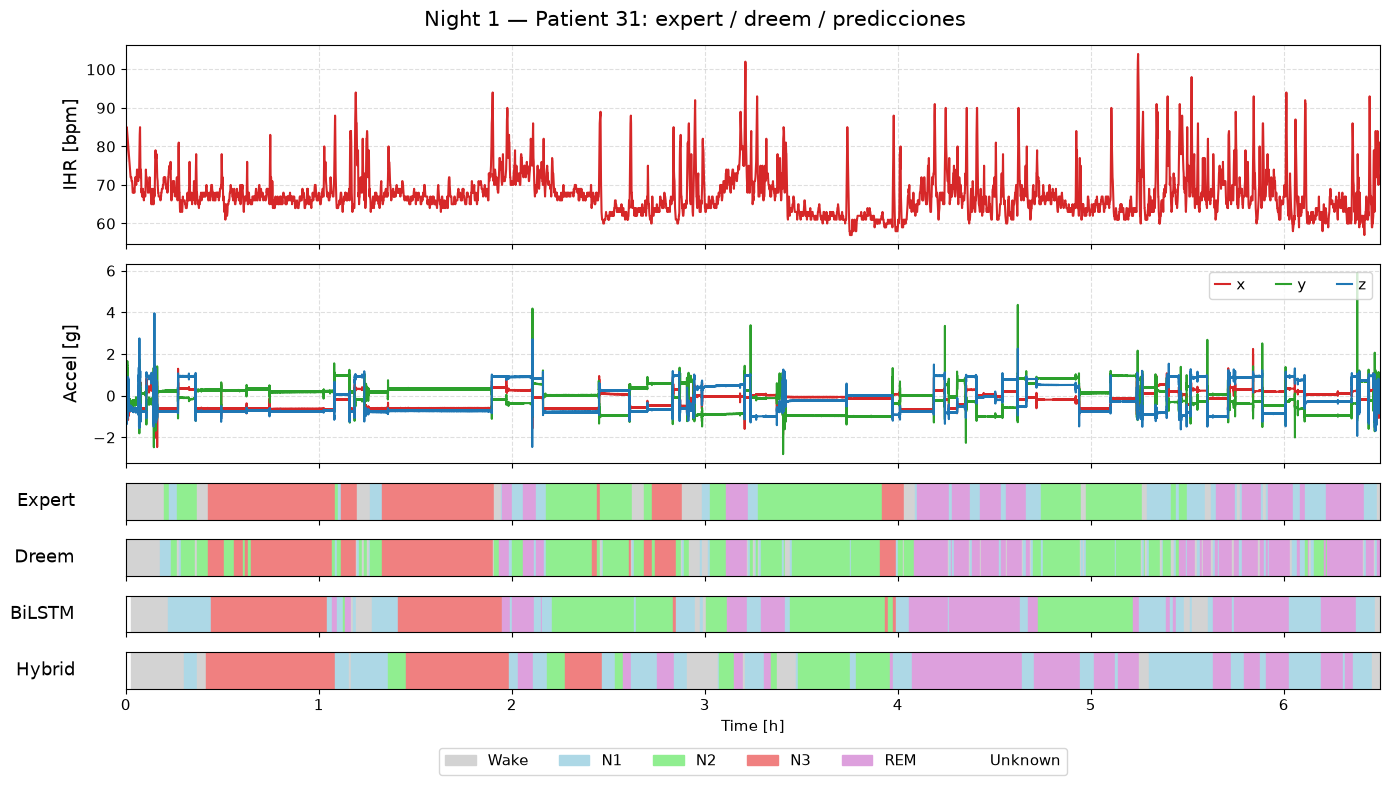

In [10]:
# una noche del test set (sujetos de test del split compartido, guardados en el checkpoint)
ckpt = torch.load(cfg_lstm.ckpt_path, map_location='cpu', weights_only=False)
subject = sorted(ckpt['subj']['test'])[1]
night = int(pd.read_csv(cfg_lstm.features_path).query('subject == @subject')['night'].min())

preds = {'BiLSTM': predict_night(model_lstm, cfg_lstm, subject, night)}
try:
    preds['Hybrid'] = predict_night(model_hyb, cfg_hyb, subject, night)
except KeyError as e:
    print(f"fila híbrido omitida: {e}")

night_prediction_overview(subject, night, preds)